# 22 — Injection-depth audit: donor morphology, dimming validation, star-donor depth

**Trigger (SH):** where do injected magnitudes come from, and is the dimming step sound?

**What this notebook established, in order:**
1. **dim vs nodim gap** — real sources injected at native brightness are recovered at 98–99% at
   mags 23–24.5 where the legacy dimmed-donor curve reads 66–93%. Same tiles, detector,
   placement, and 0.3″ matching.
2. **Null test** — empty-sky stamps trigger detections at 0.4%: the gap is not the nodim noise bump.
3. **Stamp radius** — production rerun at 3″ stamps (`--rvis 30`) reproduces the legacy depths:
   truncation vs the MER total magnitudes is not the cause either (detection keys on the core,
   which the dimming scales correctly).
4. **Donor morphology (the cause)** — the legacy 19.5–21.5 donor pool is compact *galaxies*
   (median concentration f<0.3″/f<1.5″ ≈ 0.31), while the real faint population is ~2× more
   concentrated (0.58–0.63). Dimmed, those donors are extended low-SB objects: the legacy curve
   is an extended-morphology completeness, **not** a point-source depth.
5. **Fix** — donors restricted to unresolved objects (C ≥ 0.65, pool widened to 19.5–22.5;
   `inject_eval.py --rvis 30 --donor-conc 0.65 --donor-faint 22.5`). The star-donor dim curve now
   matches the real-source validation at 23–25, and the production head reaches a point-source
   50% depth of VIS ≈ 26.6 (all ten bands) vs 26.1 (VIS-only): fusion gain +0.45 mag, unchanged.

Galleries below show the actual donor cutouts and an injection before/after so the selection can
be inspected. Caches: `_nb22_outputs/records.json` (dim-vs-nodim), and per-tile caches + metrics
under `checkpoints/q1_detection/injection_{cache,metrics}_r30_star*.json`.

In [1]:
# ============ SETUP ============
import sys, json
from pathlib import Path
import numpy as np, torch
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from astropy.wcs import WCS

def find_repo_root(s=None):
    s = (s or Path.cwd()).resolve()
    for c in [s, *s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO = find_repo_root()
for p in (REPO/'models', REPO):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
from load_foundation import load_foundation
from detection.validation_utils import (load_mer, tile_paths, build_inputs, run_detect,
                                        _wcs_vis, _stamp, _add, safe_header_from_card_string,
                                        RUBIN_BANDS, EUCLID_BANDS)
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper

DEV = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ENC  = REPO/'models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt'
CKPT = REPO/'checkpoints/q1_detection/centernet_vis_sep.pt'
MERF = REPO/'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_ECDFS_footprint.fits'
EUCLID = REPO/'data/euclid_tiles_all_q1'; RUBIN = REPO/'data/rubin_tiles_all'
OUT = REPO/'io'/'_nb22_outputs'; OUT.mkdir(exist_ok=True)
CACHE = OUT/'records.json'

BINS = (23.0, 23.5, 24.0, 24.5, 25.0); HALF = 0.2; NPER = 8
CONF = 0.30; N_TILES = 36; SEED = 7
MATCH_PX = 3.0; EDGE = 24; RVIS = 8   # same as eval_injection

mer = load_mer(str(MERF))
sky = cKDTree(np.c_[mer['cRA'], mer['cDEC']])
NN2 = sky.query(np.c_[mer['cRA'], mer['cDEC']], k=2)[0][:, 1]
ISO = NN2 > 3/3600.
stems = sorted(p.name.replace('_euclid.npz', '')
               for p in EUCLID.glob('tile_*_patch_25_euclid.npz'))[:N_TILES]
print(f'{len(stems)} held-out patch-25 tiles; bins {BINS}; {NPER}/bin/tile; conf={CONF}')

if 'DET' not in globals():
    foundation = load_foundation(str(ENC), device=torch.device('cpu'), freeze=True)
    enc = JAISPEncoderWrapper(foundation, freeze=True).to(DEV).eval()
    DET = CenterNetDetector.load(str(CKPT), encoder=enc, device=DEV).eval()
    print('production detector loaded')

36 held-out patch-25 tiles; bins (23.0, 23.5, 24.0, 24.5, 25.0); 8/bin/tile; conf=0.3
JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]


Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt
production detector loaded


In [2]:
# ============ RUN BOTH INJECTION MODES (cached per tile) ============
recs = json.load(open(CACHE)) if CACHE.exists() else {}

def compact_ok(vis, x, y):
    a, b = int(round(x)), int(round(y))
    s = vis[b-5:b+6, a-5:a+6]
    if s.size != 121: return False
    s = s - np.median(s); tot = s[s > 0].sum()
    return tot > 0 and s[3:8, 3:8][s[3:8, 3:8] > 0].sum()/tot > 0.6

def make_pend(ed, rd, ew, rw, vw, dra, ddec, tra, tdc, f):
    pend = []
    for b in EUCLID_BANDS:
        k = b.split('_', 1)[1]
        st = _stamp(np.nan_to_num(np.asarray(ed[f'img_{k}'], np.float32)), ew[k], dra, ddec, RVIS)
        if st is None: return None
        px, py = ew[k].all_world2pix(tra, tdc, 0)
        pend.append((b, int(round(float(px))), int(round(float(py))), st*f))
    for bi, b in enumerate(RUBIN_BANDS):
        st = _stamp(np.asarray(rd['img'], np.float32)[bi], rw, dra, ddec, RVIS//2)
        if st is None: return None
        px, py = rw.all_world2pix(tra, tdc, 0)
        pend.append((b, int(round(float(px))), int(round(float(py))), st*f))
    return pend

rng = np.random.default_rng(SEED)
for si, stem in enumerate(stems):
    if stem in recs:
        continue
    import glob as _g
    ep, rp = tile_paths(stem, str(EUCLID), str(RUBIN))
    if not (_g.glob(ep) and _g.glob(rp)):
        recs[stem] = {'skip': 'missing'}; continue
    ed = dict(np.load(ep, allow_pickle=True)); rd = dict(np.load(rp, allow_pickle=True))
    images0, rms, vh = build_inputs(ed, rd); H, W = vh
    vw = _wcs_vis(ed); rw = WCS(rd['wcs_hdr'].item())
    ew = {k: WCS(safe_header_from_card_string(ed[f'wcs_{k}'].item())) for k in ('VIS','Y','J','H')}
    var = np.asarray(ed['var_VIS'], np.float32); cover = np.isfinite(var) & (var > 0)
    D0 = run_detect(DET, images0, rms, vh, DEV, CONF); t0 = cKDTree(D0) if len(D0) else None
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], np.float32))

    dx, dy = vw.all_world2pix(mer['cRA'], mer['cDEC'], 0)
    din = (dx > EDGE+RVIS) & (dx < W-EDGE-RVIS) & (dy > EDGE+RVIS) & (dy < H-EDGE-RVIS) & ISO
    cin = {j: compact_ok(vis, dx[j], dy[j]) for j in np.where(din)[0]}
    good = np.array([j for j, ok in cin.items() if ok], int)
    mg = mer['cMAG']
    bright = good[(mg[good] > 19.5) & (mg[good] < 21.5)]
    binpool = {m: good[np.abs(mg[good] - m) <= HALF] for m in BINS}
    ckm = (dx >= 0) & (dx < W) & (dy >= 0) & (dy < H)
    occ = cKDTree(np.c_[dx[ckm], dy[ckm]]) if ckm.sum() else None

    def place(pool, fmode, m):
        placed, out, tries = 0, [], 0
        while placed < NPER and tries < 800:
            tries += 1
            if len(pool) == 0: break
            di = int(rng.choice(pool))
            f = 10**(-0.4*(m - mg[di])) if fmode == 'dim' else 1.0
            if f > 1: continue
            tx = rng.uniform(EDGE, W-EDGE); ty = rng.uniform(EDGE, H-EDGE)
            ix, iy = int(tx), int(ty)
            if not cover[max(0, iy-3):iy+4, max(0, ix-3):ix+4].all(): continue
            if occ is not None and occ.query([tx, ty])[0] < 10: continue
            if t0 is not None and t0.query([tx, ty])[0] < 8: continue
            tra, tdc = vw.all_pix2world(tx, ty, 0)
            pend = make_pend(ed, rd, ew, rw, vw, mer['cRA'][di], mer['cDEC'][di], tra, tdc, f)
            if pend is None: continue
            out.append((tx, ty, m, pend)); placed += 1
        return out

    tile_rec = {}
    for mode in ('dim', 'nodim'):
        inj = []
        for m in BINS:
            inj += place(bright if mode == 'dim' else binpool[m], mode, m)
        imgs = {b: images0[b].copy() for b in images0}
        for (tx, ty, m, pend) in inj:
            for (b, a, c2, s) in pend:
                _add(imgs[b], a, c2, s)
        D1 = run_detect(DET, imgs, rms, vh, DEV, CONF); t1 = cKDTree(D1) if len(D1) else None
        res = {str(m): [0, 0] for m in BINS}
        for (tx, ty, m, pend) in inj:
            res[str(m)][1] += 1
            new = (t0 is None or t0.query([tx, ty])[0] > MATCH_PX)
            if new and t1 is not None and t1.query([tx, ty])[0] < MATCH_PX:
                res[str(m)][0] += 1
        tile_rec[mode] = res
    recs[stem] = tile_rec
    json.dump(recs, open(CACHE, 'w'))
    print(f'{si+1}/{len(stems)} {stem}', flush=True)
print('done; cached ->', CACHE)

done; cached -> /home/shemmati/Work/Projects/JAISP/io/_nb22_outputs/records.json


  bin    dim rec/n   comp    nodim rec/n   comp
 23.0   269/280    96.1%     268/272    98.5%
 23.5   260/280    92.9%     285/288    99.0%
 24.0   228/280    81.4%     284/288    98.6%
 24.5   185/280    66.1%     282/288    97.9%
 25.0   124/280    44.3%     269/288    93.4%


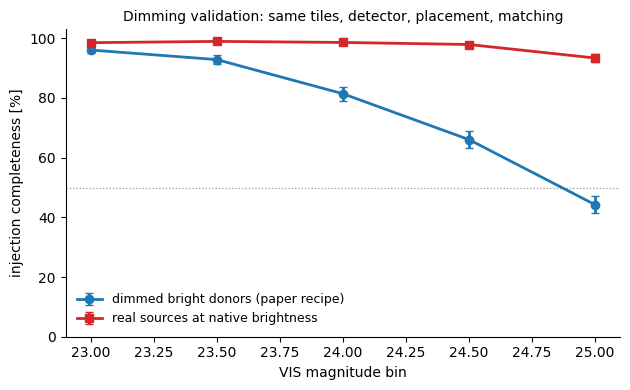

In [3]:
# ============ COMPARE ============
tot = {mode: {m: [0, 0] for m in BINS} for mode in ('dim', 'nodim')}
for stem, tr in recs.items():
    if 'skip' in tr: continue
    for mode in ('dim', 'nodim'):
        for m in BINS:
            r, n = tr[mode][str(m)]
            tot[mode][m][0] += r; tot[mode][m][1] += n

print(f'{"bin":>5} {"dim rec/n":>12} {"comp":>6}   {"nodim rec/n":>12} {"comp":>6}')
comp, err = {}, {}
for mode in ('dim', 'nodim'):
    c = np.array([100*tot[mode][m][0]/max(tot[mode][m][1], 1) for m in BINS])
    n = np.array([tot[mode][m][1] for m in BINS])
    comp[mode] = c; err[mode] = 100*np.sqrt(np.maximum(c/100*(1-c/100)/np.maximum(n, 1), 0))
for i, m in enumerate(BINS):
    d, nd = tot['dim'][m], tot['nodim'][m]
    print(f'{m:5.1f} {d[0]:5d}/{d[1]:<5d} {comp["dim"][i]:5.1f}%   {nd[0]:5d}/{nd[1]:<5d} {comp["nodim"][i]:5.1f}%')

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.errorbar(BINS, comp['dim'], err['dim'], fmt='-o', color='#1f77b4', lw=2, ms=6, capsize=3,
            label='dimmed bright donors (paper recipe)')
ax.errorbar(BINS, comp['nodim'], err['nodim'], fmt='-s', color='#d62728', lw=2, ms=6, capsize=3,
            label='real sources at native brightness')
ax.axhline(50, color='0.6', lw=0.9, ls=':')
ax.set_xlabel('VIS magnitude bin'); ax.set_ylabel('injection completeness [%]')
ax.set_ylim(0, 103); ax.legend(frameon=False, fontsize=9, loc='lower left')
ax.set_title('Dimming validation: same tiles, detector, placement, matching', fontsize=10)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout()
fig.savefig(OUT/'dim_vs_nodim.png', dpi=150, facecolor='white')
plt.show()

null test: 1/227 empty-sky stamps triggered a detection (0.4%)
--- ALL (r=30 stamps) ---
19.0-21.5   49      6.7e+09   (x1.00 vs brightest)
21.5-23.0   83     7.13e+09   (x1.06 vs brightest)
23.0-24.0  151     7.37e+09   (x1.10 vs brightest)
24.0-24.7  184     9.06e+09   (x1.35 vs brightest)
24.7-25.4  270     7.77e+09   (x1.16 vs brightest)
--- point-like (r=30 stamps) ---
--- extended (r=30 stamps) ---
19.0-21.5   45     6.69e+09   (x1.00 vs brightest)
21.5-23.0   79     7.13e+09   (x1.06 vs brightest)
23.0-24.0  151     7.37e+09   (x1.10 vs brightest)
24.0-24.7  184     9.06e+09   (x1.35 vs brightest)
24.7-25.4  270     7.77e+09   (x1.16 vs brightest)


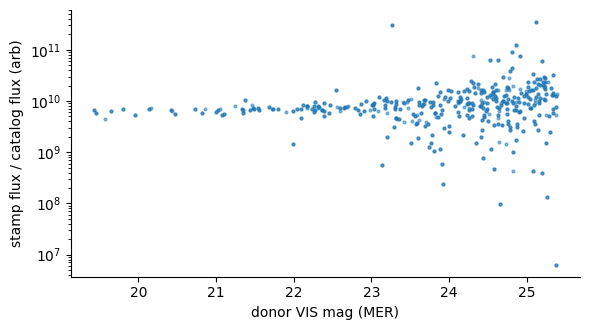

In [4]:
# ============ DIAGNOSTICS: stamp flux ratio + noise-bump null test ============
# (1) Do stamps carry the flux their catalog magnitude implies? For point sources the
#     PSF fraction inside the stamp is brightness-independent, so the ratio
#     R = (bg-subtracted VIS stamp sum) / 10^(-0.4 mag) should be FLAT with donor mag.
#     R dropping for bright donors = saturation/clipping; dropping for faint = extended donors.
# (2) Null test: inject EMPTY-sky stamps at f=1 (pure noise patches). Any "recovery" within
#     0.3" is the false-trigger rate of the carried-along noise bump, inflating nodim.
import glob as _g
rng2 = np.random.default_rng(11)
from astropy.io import fits as _fits
_cat = _fits.open(str(MERF))[1].data
_cl = (np.asarray(_cat['vis_det']) == 1) & (np.asarray(_cat['spurious_flag']) != 1)
PTL = np.asarray(_cat['point_like_flag'])[_cl]
ratios, nullrec = [], [0, 0]
for stem in stems[:12]:
    ep, rp = tile_paths(stem, str(EUCLID), str(RUBIN))
    if not (_g.glob(ep) and _g.glob(rp)): continue
    ed = dict(np.load(ep, allow_pickle=True)); rd = dict(np.load(rp, allow_pickle=True))
    images0, rms, vh = build_inputs(ed, rd); H, W = vh
    vw = _wcs_vis(ed); rw = WCS(rd['wcs_hdr'].item())
    ew = {k: WCS(safe_header_from_card_string(ed[f'wcs_{k}'].item())) for k in ('VIS','Y','J','H')}
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], np.float32))
    var = np.asarray(ed['var_VIS'], np.float32); cover = np.isfinite(var) & (var > 0)
    dx, dy = vw.all_world2pix(mer['cRA'], mer['cDEC'], 0)
    din = (dx > EDGE+RVIS) & (dx < W-EDGE-RVIS) & (dy > EDGE+RVIS) & (dy < H-EDGE-RVIS) & ISO
    for j in np.where(din)[0]:
        if not (19.0 < mer['cMAG'][j] < 25.4): continue
        if not compact_ok(vis, dx[j], dy[j]): continue
        st = _stamp(vis, ew['VIS'], mer['cRA'][j], mer['cDEC'][j], 30)
        if st is None: continue
        ratios.append((float(mer['cMAG'][j]), float(st.sum()) / 10**(-0.4*mer['cMAG'][j]), int(PTL[j])))
    # null: empty-sky stamps re-injected elsewhere at f=1
    D0 = run_detect(DET, images0, rms, vh, DEV, CONF); t0 = cKDTree(D0) if len(D0) else None
    ckm = (dx >= 0) & (dx < W) & (dy >= 0) & (dy < H)
    occ = cKDTree(np.c_[dx[ckm], dy[ckm]]) if ckm.sum() else None
    def empty_pos():
        for _ in range(400):
            tx = rng2.uniform(EDGE, W-EDGE); ty = rng2.uniform(EDGE, H-EDGE)
            ix, iy = int(tx), int(ty)
            if not cover[max(0,iy-3):iy+4, max(0,ix-3):ix+4].all(): continue
            if occ is not None and occ.query([tx, ty])[0] < 10: continue
            if t0 is not None and t0.query([tx, ty])[0] < 8: continue
            return tx, ty
        return None
    inj = []
    for _ in range(20):
        src = empty_pos(); dst = empty_pos()
        if src is None or dst is None: continue
        sra, sdc = vw.all_pix2world(src[0], src[1], 0)
        tra, tdc = vw.all_pix2world(dst[0], dst[1], 0)
        pend = make_pend(ed, rd, ew, rw, vw, sra, sdc, tra, tdc, 1.0)
        if pend is None: continue
        inj.append((dst[0], dst[1], 0.0, pend))
    imgs = {b: images0[b].copy() for b in images0}
    for (tx, ty, m, pend) in inj:
        for (b, a, c2, s) in pend: _add(imgs[b], a, c2, s)
    D1 = run_detect(DET, imgs, rms, vh, DEV, CONF); t1 = cKDTree(D1) if len(D1) else None
    for (tx, ty, m, pend) in inj:
        nullrec[1] += 1
        new = (t0 is None or t0.query([tx, ty])[0] > MATCH_PX)
        if new and t1 is not None and t1.query([tx, ty])[0] < MATCH_PX: nullrec[0] += 1

ratios = np.array(ratios)
print(f'null test: {nullrec[0]}/{nullrec[1]} empty-sky stamps triggered a detection '
      f'({100*nullrec[0]/max(nullrec[1],1):.1f}%)')
bins_m = [(19.0,21.5),(21.5,23.0),(23.0,24.0),(24.0,24.7),(24.7,25.4)]
for label, mask in (('ALL', np.ones(len(ratios), bool)),
                    ('point-like', ratios[:,2] == 1),
                    ('extended', ratios[:,2] != 1)):
    print(f'--- {label} (r=30 stamps) ---')
    med0 = None
    for lo, hi in bins_m:
        sel = mask & (ratios[:,0] >= lo) & (ratios[:,0] < hi)
        if sel.sum() < 5: continue
        med = np.median(ratios[sel,1]); med0 = med0 or med
        print(f'{lo:4.1f}-{hi:4.1f} {sel.sum():4d} {med:12.3g}   (x{med/med0:4.2f} vs brightest)')
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.semilogy(ratios[:,0], ratios[:,1], '.', ms=4, alpha=0.5)
ax.set_xlabel('donor VIS mag (MER)'); ax.set_ylabel('stamp flux / catalog flux (arb)')
for s in ('top','right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

   donor mag    N  median C(0.3/1.5as)
19.0-21.5   44               0.31
21.5-23.0   77               0.34
23.0-24.0  132               0.55
24.0-24.7  170               0.58
24.7-25.4  236               0.63


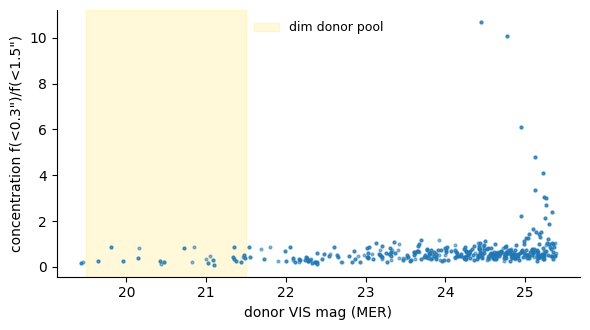

In [5]:
# ============ DONOR MORPHOLOGY: are dimmed bright donors actually point-like? ============
# Concentration C = flux(r<0.3") / flux(r<1.5") on r=30 VIS stamps, per donor pool.
# A VIS point source (PSF FWHM 0.16") has C near 1; extended galaxies fall below.
# If the bright dimming pool is systematically more extended than the real faint
# population, the "dim" curve measures extended-source completeness, not point-source depth.
import glob as _g
conc = []
for stem in stems[:12]:
    ep, rp = tile_paths(stem, str(EUCLID), str(RUBIN))
    if not (_g.glob(ep) and _g.glob(rp)): continue
    ed = dict(np.load(ep, allow_pickle=True))
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], np.float32))
    vw = _wcs_vis(ed); H, W = vis.shape
    ew_vis = WCS(safe_header_from_card_string(ed['wcs_VIS'].item()))
    dx, dy = vw.all_world2pix(mer['cRA'], mer['cDEC'], 0)
    din = (dx > EDGE+30) & (dx < W-EDGE-30) & (dy > EDGE+30) & (dy < H-EDGE-30) & ISO
    for j in np.where(din)[0]:
        if not (19.0 < mer['cMAG'][j] < 25.4): continue
        if not compact_ok(vis, dx[j], dy[j]): continue
        st = _stamp(vis, ew_vis, mer['cRA'][j], mer['cDEC'][j], 30)
        if st is None: continue
        yy, xx = np.mgrid[-30:31, -30:31]; rr = np.hypot(xx, yy)
        f15 = st[rr <= 15].sum()
        if f15 <= 0: continue
        conc.append((float(mer['cMAG'][j]), float(st[rr <= 3].sum()/f15)))
conc = np.array(conc)
hdr = 'median C(0.3/1.5as)'; print(f'{"donor mag":>12} {"N":>4} {hdr:>20}')
for lo, hi in [(19.0,21.5),(21.5,23.0),(23.0,24.0),(24.0,24.7),(24.7,25.4)]:
    sel = (conc[:,0] >= lo) & (conc[:,0] < hi)
    if sel.sum() < 5: continue
    print(f'{lo:4.1f}-{hi:4.1f} {sel.sum():4d} {np.median(conc[sel,1]):18.2f}')
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(conc[:,0], conc[:,1], '.', ms=4, alpha=0.5)
ax.set_xlabel('donor VIS mag (MER)'); ax.set_ylabel('concentration f(<0.3")/f(<1.5")')
ax.axvspan(19.5, 21.5, color='gold', alpha=0.15, label='dim donor pool')
ax.legend(frameon=False, fontsize=9)
for s in ('top','right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

legacy dim donors (19.5-21.5, C<0.65): 40 donors in first 16 tiles
star-like dim donors (19.5-22.5, C>=0.65): 21 donors in first 16 tiles
real faint sources (24.3-25.2, any C): 405 donors in first 16 tiles


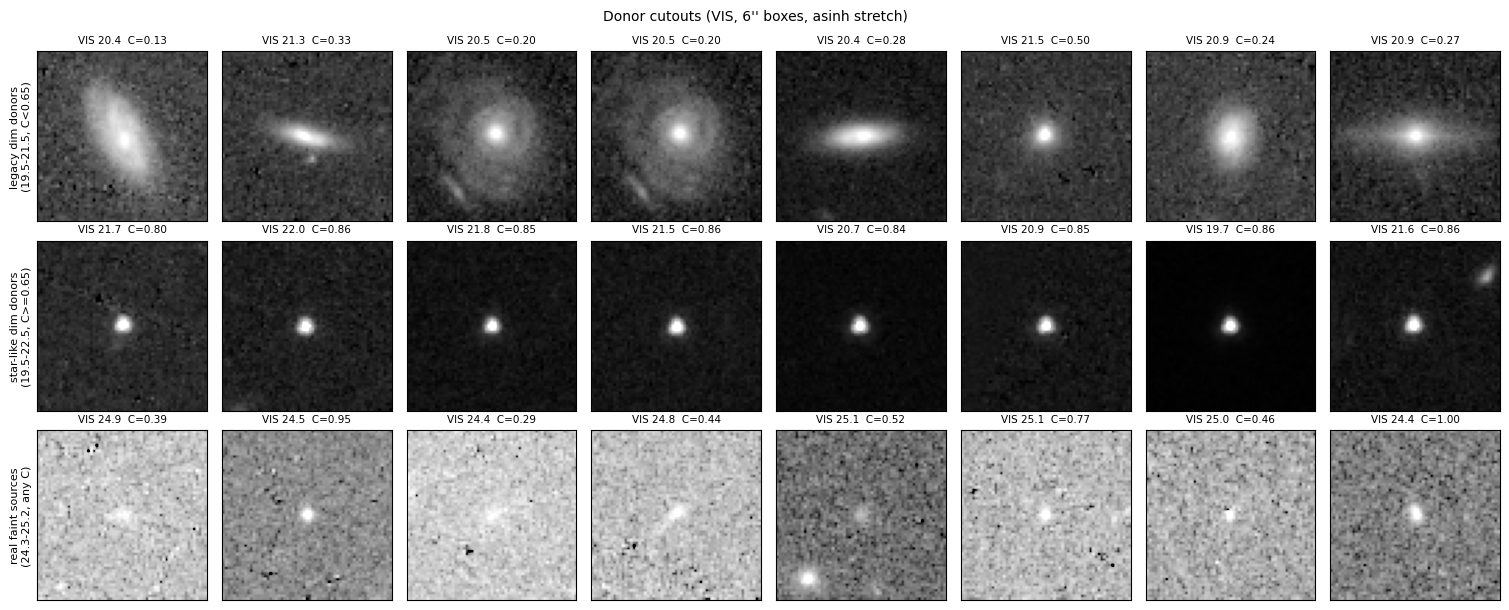

In [6]:
# ============ GALLERY: what the donor pools actually look like ============
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval
yy_g, xx_g = np.mgrid[-30:31, -30:31]; RRG = np.hypot(xx_g, yy_g)
def conc_of(st):
    f15 = st[RRG <= 15].sum()
    return float(st[RRG <= 3].sum()/f15) if f15 > 0 else np.nan

import glob as _g
pools = {'legacy dim donors\n(19.5-21.5, C<0.65)': [],
         'star-like dim donors\n(19.5-22.5, C>=0.65)': [],
         'real faint sources\n(24.3-25.2, any C)': []}
for stem in stems[:16]:
    ep, rp = tile_paths(stem, str(EUCLID), str(RUBIN))
    if not (_g.glob(ep) and _g.glob(rp)): continue
    ed = dict(np.load(ep, allow_pickle=True))
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], np.float32))
    vw = _wcs_vis(ed); H, W = vis.shape
    ew_vis = WCS(safe_header_from_card_string(ed['wcs_VIS'].item()))
    dx, dy = vw.all_world2pix(mer['cRA'], mer['cDEC'], 0)
    din = (dx > 54) & (dx < W-54) & (dy > 54) & (dy < H-54) & ISO
    for j in np.where(din)[0]:
        m = float(mer['cMAG'][j])
        if not (19.5 < m < 25.2): continue
        if not compact_ok(vis, dx[j], dy[j]): continue
        st = _stamp(vis, ew_vis, mer['cRA'][j], mer['cDEC'][j], 30)
        if st is None: continue
        C = conc_of(st)
        if 19.5 < m < 21.5 and C < 0.65: pools[list(pools)[0]].append((st, m, C))
        if 19.5 < m < 22.5 and C >= 0.65: pools[list(pools)[1]].append((st, m, C))
        if 24.3 < m < 25.2: pools[list(pools)[2]].append((st, m, C))

NSHOW = 8
fig, axes = plt.subplots(3, NSHOW, figsize=(1.9*NSHOW, 6.2))
for r, (lab, pool) in enumerate(pools.items()):
    print(f'{lab.replace(chr(10), " ")}: {len(pool)} donors in first 16 tiles')
    sel = np.linspace(0, len(pool)-1, min(NSHOW, len(pool))).astype(int)
    for ci in range(NSHOW):
        ax = axes[r][ci]; ax.set_xticks([]); ax.set_yticks([])
        if ci >= len(sel): ax.axis('off'); continue
        st, m, C = pool[sel[ci]]
        nrm = ImageNormalize(st, interval=PercentileInterval(99.7), stretch=AsinhStretch(0.05))
        ax.imshow(st, origin='lower', cmap='gray', norm=nrm)
        ax.set_title(f'VIS {m:.1f}  C={C:.2f}', fontsize=7.5)
    axes[r][0].set_ylabel(lab, fontsize=8)
fig.suptitle("Donor cutouts (VIS, 6'' boxes, asinh stretch)", fontsize=10)
plt.tight_layout(); plt.show()

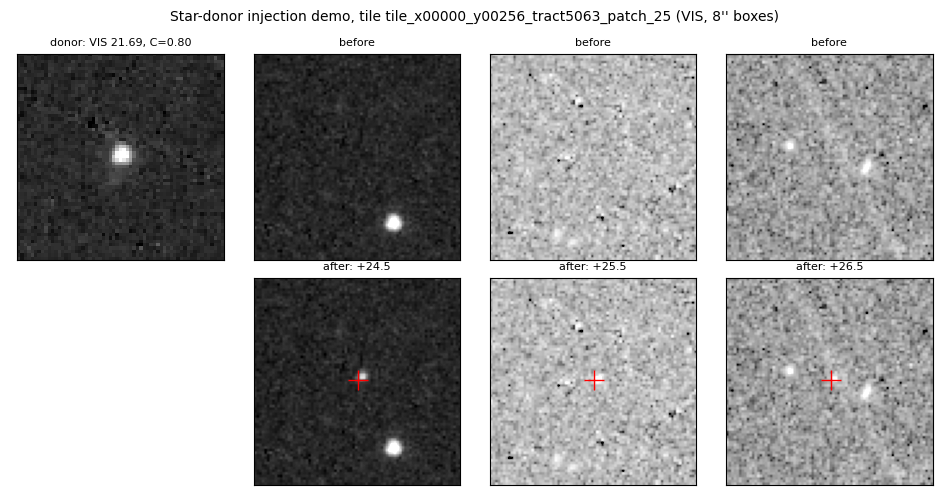

In [7]:
# ============ INJECTION DEMO: before / after with a star-like donor ============
rng3 = np.random.default_rng(21)
for stem in stems:
    ep, rp = tile_paths(stem, str(EUCLID), str(RUBIN))
    if not (_g.glob(ep) and _g.glob(rp)): continue
    ed = dict(np.load(ep, allow_pickle=True)); rd = dict(np.load(rp, allow_pickle=True))
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], np.float32))
    vw = _wcs_vis(ed); H, W = vis.shape
    ew = {k: WCS(safe_header_from_card_string(ed[f'wcs_{k}'].item())) for k in ('VIS','Y','J','H')}
    rw = WCS(rd['wcs_hdr'].item())
    dx, dy = vw.all_world2pix(mer['cRA'], mer['cDEC'], 0)
    din = (dx > 54) & (dx < W-54) & (dy > 54) & (dy < H-54) & ISO
    star = [j for j in np.where(din)[0]
            if 19.5 < mer['cMAG'][j] < 22.5 and compact_ok(vis, dx[j], dy[j])]
    star = [j for j in star
            if (lambda st: st is not None and conc_of(st) >= 0.65)(
                _stamp(vis, ew['VIS'], mer['cRA'][j], mer['cDEC'][j], 30))]
    if star: break
di = star[0]; dmag = float(mer['cMAG'][di])
var = np.asarray(ed['var_VIS'], np.float32); cover = np.isfinite(var) & (var > 0)
ckm = (dx >= 0) & (dx < W) & (dy >= 0) & (dy < H)
occ = cKDTree(np.c_[dx[ckm], dy[ckm]])
def empty_pos():
    while True:
        tx = rng3.uniform(80, W-80); ty = rng3.uniform(80, H-80)
        if cover[int(ty)-3:int(ty)+4, int(tx)-3:int(tx)+4].all() and occ.query([tx, ty])[0] > 12:
            return tx, ty
TARGETS = (24.5, 25.5, 26.5); R = 40
fig, axes = plt.subplots(2, len(TARGETS)+1, figsize=(2.4*(len(TARGETS)+1), 5))
dst = _stamp(vis, ew['VIS'], mer['cRA'][di], mer['cDEC'][di], 30)
nrm0 = ImageNormalize(dst, interval=PercentileInterval(99.7), stretch=AsinhStretch(0.05))
axes[0][0].imshow(dst, origin='lower', cmap='gray', norm=nrm0)
axes[0][0].set_title(f'donor: VIS {dmag:.2f}, C={conc_of(dst):.2f}', fontsize=8)
axes[1][0].axis('off')
for k, tm in enumerate(TARGETS):
    tx, ty = empty_pos(); tra, tdc = vw.all_pix2world(tx, ty, 0)
    f = 10**(-0.4*(tm - dmag))
    pend = make_pend(ed, rd, ew, rw, vw, mer['cRA'][di], mer['cDEC'][di], tra, tdc, f)
    visA = vis.copy()
    for (b, a, c2, s) in pend:
        if b == 'euclid_VIS': _add(visA, a, c2, s)
    iy, ix = int(ty), int(tx)
    cutB = vis[iy-R:iy+R, ix-R:ix+R]; cutA = visA[iy-R:iy+R, ix-R:ix+R]
    nrm = ImageNormalize(cutA, interval=PercentileInterval(99.7), stretch=AsinhStretch(0.1))
    for row, cut, lab in ((0, cutB, 'before'), (1, cutA, f'after: +{tm:.1f}')):
        ax = axes[row][k+1]
        ax.imshow(cut, origin='lower', cmap='gray', norm=nrm)
        ax.plot(R, R, '+', color='red' if row else 'none', ms=14, mew=1.0)
        ax.set_title(lab, fontsize=8)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Star-donor injection demo, tile {stem} (VIS, 8'' boxes)", fontsize=10)
plt.tight_layout(); plt.show()

point-source 50% depth: all-band 26.59, VIS-only 26.14, fusion gain +0.45 mag
legacy (extended-morphology) numbers were: all 25.04, VIS 24.59, gain +0.45


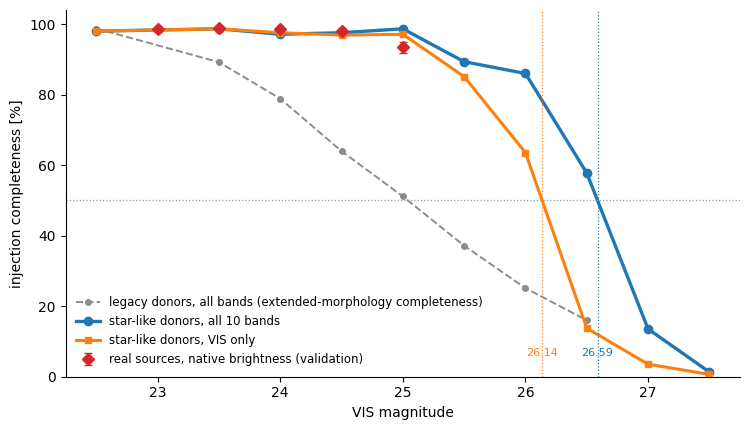

In [8]:
# ============ FINAL CURVES: legacy vs star-donor vs real-source validation ============
Q1D = REPO/'checkpoints'/'q1_detection'
legacy = json.load(open(Q1D/'injection_metrics.json'))['cn_vis_sep']['curves']
star   = json.load(open(Q1D/'injection_metrics_r30_star.json'))['cn_vis_sep']['curves']
deep   = json.load(open(Q1D/'injection_metrics_r30_star_deep.json'))['cn_vis_sep']['curves']
sm = {mode: (star[mode]['mag'] + deep[mode]['mag'],
             star[mode]['comp'] + deep[mode]['comp']) for mode in ('all', 'vis')}

def d50(mags, comp):
    mags, comp = np.asarray(mags, float), np.asarray(comp, float)
    for i in range(len(mags)-1):
        if comp[i] >= 50 >= comp[i+1]:
            return mags[i] + 0.5*(comp[i]-50)/(comp[i]-comp[i+1]+1e-9)*(mags[i+1]-mags[i])*2
    return None
D = {m: d50(*sm[m]) for m in sm}
print(f"point-source 50% depth: all-band {D['all']:.2f}, VIS-only {D['vis']:.2f}, "
      f"fusion gain +{D['all']-D['vis']:.2f} mag")
print(f"legacy (extended-morphology) numbers were: all 25.04, VIS 24.59, gain +0.45")

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(legacy['all']['mag'], legacy['all']['comp'], '--o', color='0.55', ms=4, lw=1.4,
        label='legacy donors, all bands (extended-morphology completeness)')
ax.plot(*sm['all'], '-o', color='#1f77b4', lw=2.4, ms=6, label='star-like donors, all 10 bands')
ax.plot(*sm['vis'], '-s', color='#ff7f0e', lw=2.2, ms=5, label='star-like donors, VIS only')
ax.errorbar(BINS, comp['nodim'], err['nodim'], fmt='D', color='#d62728', ms=6, capsize=3,
            label='real sources, native brightness (validation)')
for x, c_, lab in ((D['all'], '#1f77b4', f"{D['all']:.2f}"), (D['vis'], '#ff7f0e', f"{D['vis']:.2f}")):
    ax.axvline(x, color=c_, lw=0.9, ls=':'); ax.text(x, 6, lab, color=c_, fontsize=8, ha='center')
ax.axhline(50, color='0.6', lw=0.9, ls=':')
ax.set_xlabel('VIS magnitude'); ax.set_ylabel('injection completeness [%]')
ax.set_ylim(0, 104); ax.legend(fontsize=8.5, frameon=False, loc='lower left')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout()
fig.savefig(OUT/'star_donor_depth.png', dpi=150, facecolor='white')
plt.show()